# Imports

In [7]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from MC2PCA import MC2PCA
from metrics import ClusteringMetrics
from dataset_manager import DatasetManager

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
)
from scipy.optimize import linear_sum_assignment

np.random.seed(0)


# Loading data

In [8]:
ds = DatasetManager("spoken_arabic_digits")
X_train, y_train = ds.X, ds.y

# Training of the model 

In [3]:
y_true_int = np.array(y_train).astype(int)

metrics = ClusteringMetrics()

for p in [1,2,3,4,5]:
    model = MC2PCA(p=p, tol=1e-7, max_iter=100)
    model.fit(X_train, K=10)

    metrics.add_run(
        y_true=y_true_int,
        y_pred=model.assignments,
        p=p,
        X=X_train
    )


KeyboardInterrupt: 

# Evaluation

p=1 | ARI=0.158 | NMI=0.286 | Purity=0.362
p=2 | ARI=0.188 | NMI=0.344 | Purity=0.410
p=3 | ARI=0.178 | NMI=0.314 | Purity=0.388
p=4 | ARI=0.159 | NMI=0.312 | Purity=0.381
p=5 | ARI=0.113 | NMI=0.228 | Purity=0.317


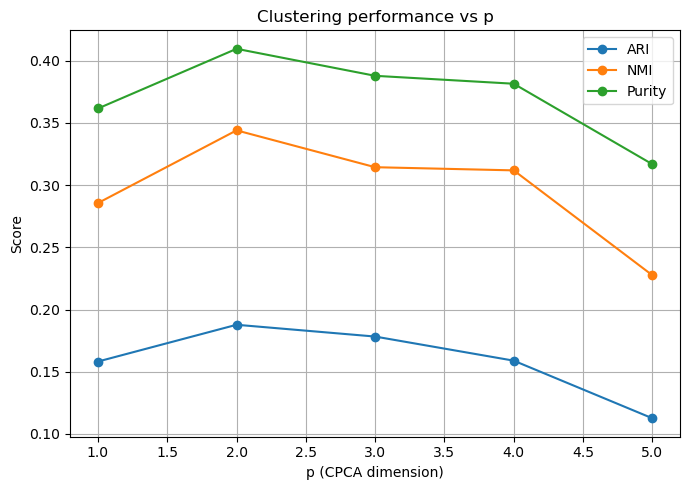

/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


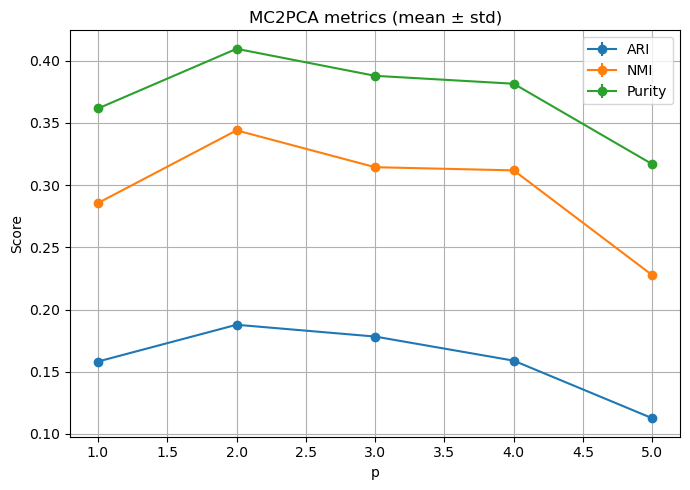

In [ ]:
metrics.summary()
metrics.plot_metrics_vs_p()
metrics.plot_metrics_mean_std()
#metrics.plot_clusters_tsne(run_id=2)

# Variation of the number of clusters

In [12]:
Ks = [8, 9, 10, 11]
p = 3
n_runs = 5

results = {}

for K in Ks:
    metrics = ClusteringMetrics()

    for run in range(n_runs):
        np.random.seed(run)

        model = MC2PCA(p=p, tol=1e-7, max_iter=30)
        model.fit(X_train, K=K)

        metrics.add_run(
            y_true=y_train,
            y_pred=model.assignments,
            errors=model.errors
        )

    purities = [r["Purity"] for r in metrics.results]

    results[K] = {
        "mean": np.mean(purities),
        "std": np.std(purities),
        "metrics": metrics
    }

    print(
        f"K={K} | Purity = "
        f"{np.mean(purities):.3f} ± {np.std(purities):.3f}"
    )


K=8 | Purity = 0.334 ± 0.000
K=9 | Purity = 0.351 ± 0.000
K=10 | Purity = 0.389 ± 0.000
K=11 | Purity = 0.410 ± 0.000


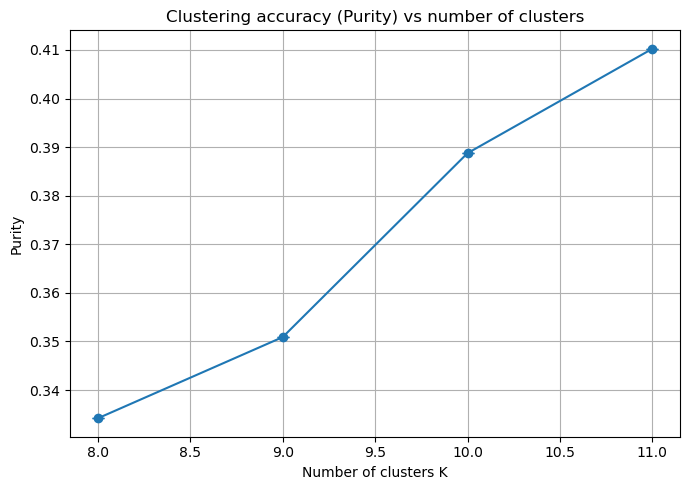

In [13]:
means = [results[k]["mean"] for k in Ks]
stds  = [results[k]["std"]  for k in Ks]

plt.figure(figsize=(7,5))
plt.errorbar(Ks, means, yerr=stds, marker="o", capsize=4)

plt.xlabel("Number of clusters K")
plt.ylabel("Purity")
plt.title("Clustering accuracy (Purity) vs number of clusters")
plt.grid(True)
plt.tight_layout()
plt.show()
